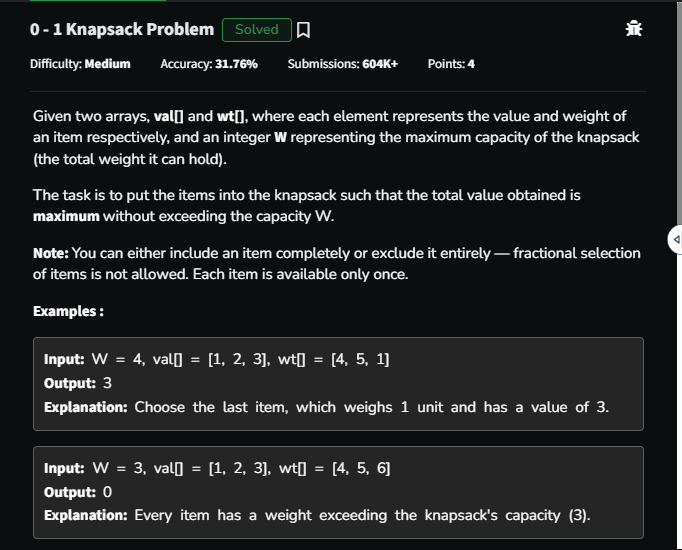
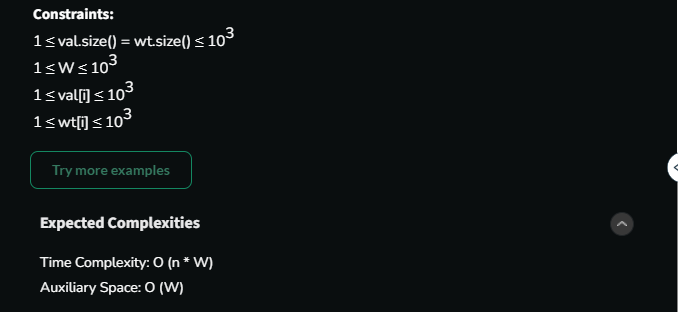

In [ ]:
# TLE
class Solution:
    def knapsack(self, W, val, wt):
        # code here
        n = len(wt)
        return self.func(W, n - 1, val, wt)
        
    def func(self, w, idx, val, wt):
        
        # Base Cond
        if idx == -1 or w == 0:
            return 0
        
        # Select
        if wt[idx] <= w:
            return max(val[idx] + self.func(w - wt[idx], idx - 1, val, wt), 
            self.func(w, idx - 1, val, wt))
            
        return self.func(w, idx - 1, val, wt)

What does dp[i][j] represent?

We used
solve(index, capacity)

Meaning:
Maximum value obtainable using items from 0...index with remaining capacity 'capacity'.

Example:

Weights
1 2 4

Values
10 20 30

Capacity=5

Suppose

dp[1][3]

What does it mean?
Using only

item0
item1

Maximum value possible with capacity
3

dp array:

          Capacity

        0 1 2 3 4 5

Item0   0 10 10 10 10 10

Item1   0 10 20 30 30 30

Item2   0 10 20 30 30 40

Answer
30  (max of row 0 == 10 + max of row 1 == 20)

How Many cells are filled?

Suppose recursion starts

solve(2,5)

The recursion tree becomes

solve(2,5)

├── solve(1,5)
│      ├── solve(0,5)
│      └── solve(0,3)
│
└── solve(1,1)
       └── solve(0,1)

Notice

It never visits

solve(2,4)

solve(2,3)

solve(2,2)

solve(2,1)

solve(1,2)

solve(1,4)

Therefore

dp

      0 1 2 3 4 5

0     - - - - - -

1     - 10 - - - 30

2     - - - - - 40

Most cells remain empty.

Memoization computes only the states recursion needs.

In [ ]:
class Solution:
    def knapsack(self, W, val, wt):
        # code here
        n = len(wt)
        # m = len(val)
        dp = [[None] * (W + 1) for _ in range(n)]
        
        return self.func(W, n - 1, val, wt, dp)
        
    def func(self, w, idx, val, wt, dp):
        
        # Base Cond
        if idx == 0:
            if wt[0] <= w:
                return val[0]
            return 0
            
        if dp[idx][w] is not None:
            return dp[idx][w]
            
        not_take = self.func(w, idx - 1, val, wt, dp)
        
        # Select
        take = 0
        if wt[idx] <= w:
            take = val[idx] + self.func(w - wt[idx], idx - 1, val, wt, dp)
        
        dp[idx][w] = max(take, not_take)
        
        return dp[idx][w]

What does dp[i][j] represent?

Same as memoization

Weights
1 2 4

Values
10 20 30

Capacity=5

Tabulation fills

Item (Idx)	Weight	Value	Cap 0	Cap 1	Cap 2	Cap 3	Cap 4	Cap 5
0 (None)	-	        -	   0	  0	     0	      0	     0	    0
1 (W=1)	     1	        10	   0	   10	  10	 10	    10	    10
2 (W=2)	     2	        20	    0	   10	  20	 30	    30	    30
3 (W=4)	     4	        30	    0	   10	  20	 30	    40	    50

Every cell is filled.

In [ ]:
class Solution:
    def knapsack(self, W, val, wt):
        # code here
        n = len(wt)
        # m = len(val)
        dp = [[0] * (W + 1) for _ in range(n + 1)]
        
        # for i in range(n + 1):
        #     dp[i][0] = 0
            
        # for i in range(W + 1):
        #     dp[0][i] = 0
        
        for i in range(1, n + 1):
            for j in range(1, W + 1):
                if wt[i - 1] <= j:
                    dp[i][j] = max(val[i - 1] + dp[i - 1][j - wt[i - 1]], dp[i - 1][j])
                else:
                    dp[i][j] = dp[i - 1][j]
                
        return dp[n][W]
        
    

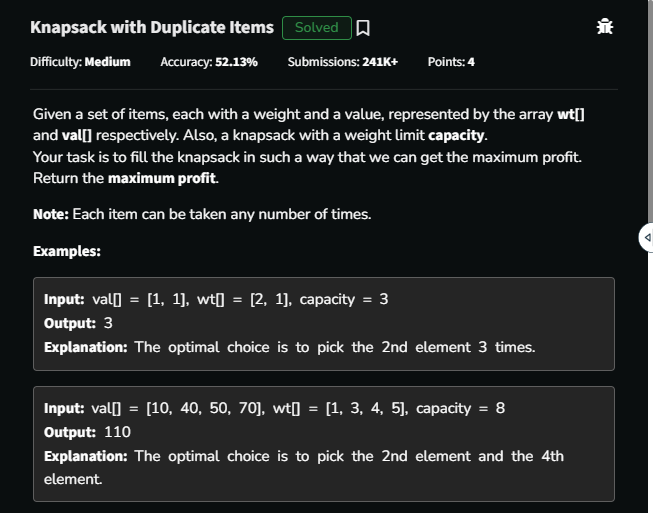
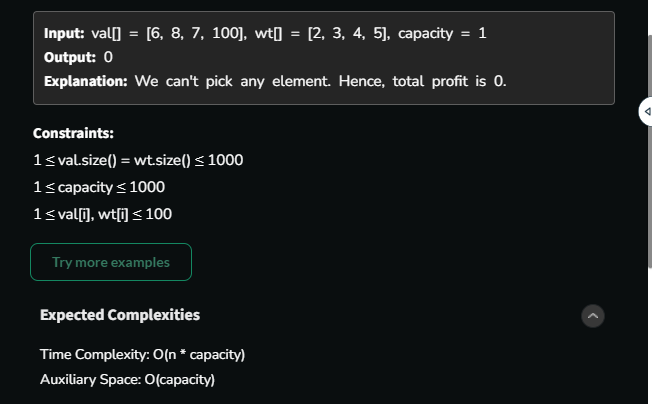

Unbounded Knapsack

Transition:

take = value + dp[i][j-weight]

Now the dependency is in the same row.

Current Row

□ → □ → □ → □ → □

Each cell depends on a cell to its left.

So we must move left to right.

In [ ]:
class Solution:
    def knapSack(self, val, wt, capacity):
        # code here
        self.val = val
        self.wt = wt
        N = len(val)
        
        return self.max_profit(N - 1, capacity)
        
    def max_profit(self, n, w):
        
        if n == -1 or w == 0:
            return 0
            
        if self.wt[n] <= w:
            return max(self.val[n] + self.max_profit(n, w - self.wt[n]), self.max_profit(n - 1, w))
        else:
            return self.max_profit(n - 1, w)
            
            

What does dp[i][j] represent?

dp[index][capacity]

means
Maximum obtainable value using:
0...index

with capacity:
capacity

How many cells are filled?

Only visited states.


In [ ]:
class Solution:
    def knapSack(self, val, wt, capacity):
        # code here
        self.val = val
        self.wt = wt
        N = len(val)
        
        self.dp = [[-1] * (capacity + 1) for _ in range(N + 1)]
        
        return self.max_profit(N, capacity)
        
    def max_profit(self, n, w):
        
        if n == 0 or w == 0:
            return 0
            
        if self.dp[n][w] != -1:
            return self.dp[n][w]
            
        if self.wt[n - 1] <= w:
            self.dp[n][w] =  max(self.val[n - 1] + self.max_profit(n, w - self.wt[n - 1]), self.max_profit(n - 1, w))
        else:
            self.dp[n][w] = self.max_profit(n - 1, w)
            
        return self.dp[n][w]
            

What does dp[i][j] represent?

same, as memo

How many cells are filled?

Entire table.

Example:

Weights
1 2 4

Values
10 20 30

Capacity=5

Suppose

dp[1][3]

Item (Idx)	Weight	Value	Cap 0	Cap 1	Cap 2	Cap 3	Cap 4	Cap 5
0     (None)	-	   -	0	     0	     0	     0	      0	      0
1     (W=1)	    1	  10	0	    10	     20	     30	     40	      50
2     (W=2)	    2	  20	0	    10	     20	     30	     40	      50
3     (W=4)	    4	  30	0	    10	     20	     30	     40	      50

Answer:
60

In [ ]:
class Solution:
    def knapSack(self, val, wt, capacity):
        # code here
        self.val = val
        self.wt = wt
        n = len(val)
        
        self.dp = [[0] * (capacity + 1) for _ in range(n + 1)]
        
        # for i in range(n + 1):
        #     self.dp[i][0] = 0
        # for j in range(capacity + 1):
        #     self.dp[0][i] = 0
            
        for i in range(1, n + 1):
            for j in range(1, capacity + 1):
                if self.wt[i - 1] <= j:
                    self.dp[i][j] =  max(self.val[i - 1] + self.dp[i][j - self.wt[i - 1]], self.dp[i - 1][j])
                else:
                    self.dp[i][j] = self.dp[i - 1][j]
                    
        return self.dp[n][capacity]
        

Subset Sum Problem

In [ ]:
class Solution:
    def isSubsetSum(self, arr, target):
        n = len(arr)
        return self.solve(n - 1, target, arr)
    
    def solve(self, n, x, arr):

        # base case
        if x == 0:
            return True
            
        if n < 0:
            return False

        # take
        if arr[n] <= x:
            return self.solve(n - 1, x - arr[n], arr) or self.solve(n - 1, x, arr)

        # leave
        return self.solve(n - 1, x, arr)

# soln = Solution()
# print(soln.SubsetSum([3, 34, 4, 12, 5, 2], 9))

False


In [ ]:
class Solution:
    def isSubsetSum(self, arr, target):
        n = len(arr)
        self.dp = [[-1] * (target + 1) for _ in range(n)]
        return self.solve(n - 1, target, arr)
    
    def solve(self, n, x, arr):

        # base case
        if x == 0:
            return True
            
        if n < 0:
            return False
        # if n == 0:
        #     if arr[n] == x:
        #         self.dp[n][x] = True
        #         # return self.dp[n][x]
        #     else:
        #         self.dp[n][x] = False
        #     return self.dp[n][x]

        # avoid redundant function calls 
        if self.dp[n][x] != -1:
            return self.dp[n][x]

        # take
        if arr[n] <= x:
            self.dp[n][x] = self.solve(n - 1, x - arr[n], arr) or self.solve(n - 1, x, arr)

        # leave
        else:
            self.dp[n][x] = self.solve(n - 1, x, arr)

        return self.dp[n][x]

# soln = Solution()
# print(soln.SubsetSum([3, 34, 4, 12, 5, 2], 30))

False


1. What does each cell of the DP array represent?
Each cell dp[i][j] is a boolean (True or False) that answers the question:

"Is it possible to form a sum of exactly j using a subset of the first i elements of the array?"

2. What do the First Row and First Column represent?

-First Row (i = 0): Represents considering 0 items (an empty set).

It is impossible to form any sum j > 0 with no items.
Therefore, dp[0][j] is False for all j > 0.

-First Column (j = 0): Represents a target sum of 0.

It is always possible to form a sum of 0 by choosing an empty subset, regardless of how many items are available.
Therefore, dp[i][0] is True for all i.

Example:
arr = [1, 2, 3], target = 5

Row (i)	Items Considered	Sum 0	Sum 1	Sum 2	Sum 3	Sum 4	Sum 5
0	    None	             T	      F	      F	      F	      F	     F
1	    {1}	                 T	      T	      F	      F	      F	     F
2	    {1, 2}	             T	      T	      T	      T	      F	     F
3	    {1, 2, 4}	         T	      T	      T	      T	      T	     T

In [ ]:
class Solution:
    def SubsetSum(self, arr, target):
        n = len(arr)
        dp = [[False] * (target + 1) for _ in range(n + 1)]
        # return self.solve(n - 1, target, arr)
        
        # initializing the first column of the dp mat
        for i in range(n + 1):
            dp[i][0] = True

        for i in range(1, n + 1):
            for j in range(1, target + 1):

                # take
                if arr[i - 1] <= j:
                    dp[i][j] = dp[i - 1][j - arr[i]] or dp[i - 1][j]
                
                # leave
                else:
                    dp[i][j] = dp[i - 1][j]
                
        return dp[n][target]
    

soln = Solution()
print(soln.SubsetSum([3, 34, 4, 12, 5, 2], 9))

False


Partition Equal Subset Sum

In [ ]:
class Solution:
    def isPartition(self, arr):
        add = sum(arr)
        n = len(arr)
        if add & 1 == 1:
            return False
        else:
            return self.solve(arr, add // 2, n - 1)

    def solve(self, arr, x, n):

        # base case
        if x == 0:
            return True

        if n < 0:
            return False

        if arr[n] <= x:
            return self.solve(arr, x - arr[n], n - 1 ) or self.solve(arr, x, n - 1)

        else:
            return self.solve(arr, x, n - 1)

        

In [ ]:
# Memoization soln

class Solution:
    def isPartition(self, arr):
        add = sum(arr)
        n = len(arr)
        
        if add & 1 == 1:
            return False
        else:
            x = add // 2
            self.dp = [[0] * (x + 1) for _ in range(n + 1)]
            return self.solve(arr, x, n - 1)

    def solve(self, arr, x, n):

        # base case
        if x == 0:
            return True

        if n < 0:
            return False

        # avoid redundant funtion calls
        if self.dp[n][x] != 0:
            return self.dp[n][x]

        if arr[n] <= x:
            self.dp[n][x] = self.solve(arr, x - arr[n], n - 1 ) or self.solve(arr, x, n - 1)

        else:
            self.dp[n][x] = self.solve(arr, x, n - 1)

        return self.dp[n][x]

        

In [ ]:
# Tabulation soln

class Solution:
    def equalPartition(self, arr):
        # code here
        add = sum(arr)
        n = len(arr)
        
        if add & 1 == 1:
            return False
        else:
            x = add // 2
            self.dp = [[False] * (x + 1) for _ in range(n + 1)]

            # handling the first column
            for i in range(n + 1):
                self.dp[i][0] = True

            for i in range(1, n + 1):
                for j in range(1, x + 1):
                    if arr[i - 1] <= j:
                        self.dp[i][j] = self.dp[i - 1][j - arr[i - 1]] or self.dp[i - 1][j]
                    
                    else:
                        self.dp[i][j] = self.dp[i - 1][j]

        return self.dp[n][x]

coin change minimum coins

In [ ]:

class Solution:
	def minCoins(self, coins, sum):
        # coins.sort()
        n = len(coins)
        
        return self.solve(coins, n - 1, sum)
        
    def solve(self, arr, n, x):
        
        if x == 0:
            return 0
            
        if n < 0:
            return float('inf')
            
        if arr[n] <= x:
            return min(1 + self.solve(arr, n, x - arr[n]), self.solve(arr, n - 1, x))
    	else:
    	    return self.solve(arr, n - 1, x)

In [ ]:

class Solution:
	def minCoins(self, coins, sum):
        # coins.sort()
        n = len(coins)

        self.dp = [[-1] * (sum + 1) for _ in range(n + 1)]
        
        return self.solve(coins, n, sum)
        
    def solve(self, arr, n, x):
        
        if x == 0:
            return 0
            
        if n < 0:
            return float('inf')

        if self.dp[n][x] != -1:
            return self.dp[n][x]
            
        if arr[n - 1] <= x:
            self.dp[n][x] =  min(1 + self.solve(arr, n, x - arr[n - 1]), self.solve(arr, n - 1, x))
    	else:
    	    self.dp[n][x] =  self.solve(arr, n - 1, x)

        return self.dp[n][x]

In [ ]:

class Solution:
	def minCoins(self, coins, sum):
        # coins.sort()
        n = len(coins)

        self.dp = [[-1] * (sum + 1) for _ in range(n + 1)]

        for i in range(n + 1):
            self.dp[i][0] = -1
        
        return self.solve(coins, n, sum)
        
    def solve(self, arr, n, x):
        
        if x == 0:
            return 0
            
        if n < 0:
            return float('inf')

        if self.dp[n][x] != -1:
            return self.dp[n][x]
            
        if arr[n - 1] <= x:
            self.dp[n][x] =  min(1 + self.solve(arr, n, x - arr[n - 1]), self.solve(arr, n - 1, x))
    	else:
    	    self.dp[n][x] =  self.solve(arr, n - 1, x)

        return self.dp[n][x]